<a href="https://colab.research.google.com/github/meenakshi16rp/02-Vanilla-Autoencoder-FashionMNIST/blob/main/FASHION_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
transform = transforms.ToTensor()

In [4]:
import matplotlib.pyplot as plt

In [5]:
train_dataset= datasets.FashionMNIST(
    root="./data",
    train= True,
    download= True,
    transform= transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.47MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.0MB/s]


In [6]:
test_dataset = datasets.FashionMNIST(
    root="./data",
    train = False,
    download= True,
    transform= transform
)

In [7]:
batch_size = 64

In [8]:
train_loader= DataLoader(
    train_dataset,
    batch_size= batch_size,
    shuffle= True
)

In [9]:
test_loader= DataLoader(
    test_dataset,
    batch_size= batch_size,
    shuffle= True
)

In [10]:
print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

Training Images : 60000
Testing Images  : 10000


In [11]:
images, labels = next(iter(train_loader))

In [12]:
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [14]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

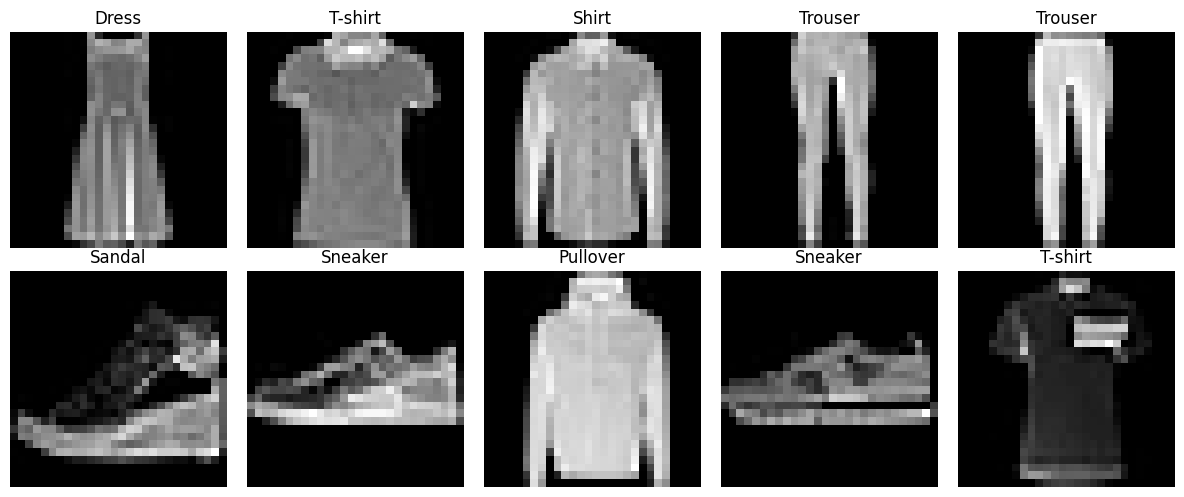

In [15]:
plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(class_names[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [17]:
print(images)

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..

In [20]:
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()

    self.encoder = nn.Sequential(

            nn.Linear(784,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,32)
    )
    def forward(self,x):
        return self.encoder(x)

In [21]:
class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.decoder = nn.Sequential(

            nn.Linear(32,64),
            nn.ReLU(),

            nn.Linear(64,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,784),

            nn.Sigmoid()
        )

    def forward(self,x):
        return self.decoder(x)

In [22]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()

        self.decoder = Decoder()

    def forward(self,x):

        latent = self.encoder(x)

        reconstructed = self.decoder(latent)

        return reconstructed

In [23]:
model = Autoencoder()

print(model)

Autoencoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Linear(in_features=784, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=256, bias=True)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=784, bias=True)
      (7): Sigmoid()
    )
  )
)
